In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import pandas as pd


In [3]:
import pandas as pd
# On regarde les colonnes du fichier fusionné
df = pd.read_csv('raw_data/gros_dataset_brut.csv')
print("--- TES COLONNES ACTUELLES ---")
print(df.columns.tolist())

--- TES COLONNES ACTUELLES ---
['HourUTC', 'PriceArea', 'SpotPriceEUR', 'SpotPriceDKK', 'mFRRUpActBal', 'mFRRDownActBal', 'mFRRUpActSpec', 'mFRRDownActSpec', 'ImbalanceMWh', 'ImbalancePriceEUR', 'BalancingPowerPriceUpEUR', 'BalancingPowerPriceDownEUR', 'Brute_Consumption_MWh']


In [4]:
# 1. Chargement du nouveau dataset
df = pd.read_csv('raw_data/gros_dataset_brut.csv')
df['HourUTC'] = pd.to_datetime(df['HourUTC'])
df = df.sort_values(['HourUTC', 'PriceArea'])

# ==========================================================
# TEST 1 : L'INTÉGRITÉ TEMPORELLE (Le métronome)
# ==========================================================
def check_continuity(group):
    # freq='h' pour compatibilité Pandas 2.x
    expected_range = pd.date_range(start=group['HourUTC'].min(), end=group['HourUTC'].max(), freq='h')
    missing = expected_range.difference(group['HourUTC'])
    return len(missing), missing

print("--- AUDIT 1 : CONTINUITÉ TEMPORELLE ---")
for zone in ['DK1', 'DK2']:
    m_count, m_hours = check_continuity(df[df['PriceArea'] == zone])
    print(f"Zone {zone} : {m_count} heures manquantes dans la timeline.")
    if m_count > 0:
        print(f"   ⚠️ Premier saut détecté à : {m_hours[0]}")

# ==========================================================
# TEST 2 : ANALYSE GLOBALE DES NaNs
# ==========================================================
print("\n--- AUDIT 2 : VALEURS MANQUANTES (NaNs) ---")
nan_report = df.isna().sum()
nan_report = nan_report[nan_report >= 0] # On affiche tout pour être exhaustif
print(nan_report)

# ==========================================================
# TEST 3 : ANALYSE DES SÉQUENCES (STREAKS)
# ==========================================================
# On vérifie la plus longue suite de NaNs pour tes cibles et features clés
def max_nan_streak(series):
    return series.isna().astype(int).groupby(series.notna().cumsum()).sum().max()

print("\n--- AUDIT 3 : LONGUEUR MAX DES TROUS (STREAKS) ---")
# On adapte les colonnes à ton nouveau schéma
target_cols = ['SpotPriceEUR', 'mFRRUpActBal', 'ImbalancePriceEUR', 'Brute_Consumption_MWh']
for col in target_cols:
    if col in df.columns:
        streak = max_nan_streak(df[col])
        print(f"Plus longue suite de NaNs pour {col} : {streak} heures")

# ==========================================================
# TEST 4 : ANALYSE DE CORRÉLATION (Audit Métier)
# ==========================================================
print("\n--- AUDIT 4 : CORRÉLATION SPOT VS IMBALANCE ---")
if 'SpotPriceEUR' in df.columns and 'ImbalancePriceEUR' in df.columns:
    # On calcule la corrélation sur les données non-nulles
    corr = df[['SpotPriceEUR', 'ImbalancePriceEUR']].dropna().corr().iloc[0,1]
    print(f"Coefficient de corrélation : {corr:.4f}")
    if corr > 0.9:
        print("   💡 Note : Très forte corrélation. L'imbalance suit de près le spot.")
    elif corr < 0.5:
        print("   ⚠️ Note : Faible corrélation. Le marché d'imbalance est très spécifique (chaotique).")

# ==========================================================
# TEST 5 : ENCODAGE ET VÉRIFICATION TYPES
# ==========================================================
# Binarisation
df['Is_DK2'] = (df['PriceArea'] == 'DK2').astype(int)

print("\n--- AUDIT 5 : TYPES ET ENCODAGE ---")
print(df.dtypes)

# Challenge additionnel : Est-ce que "NaN" dans mFRR veut dire 0 ?
if 'mFRRUpActBal' in df.columns:
    zeros = (df['mFRRUpActBal'] == 0).sum()
    print(f"\nNombre de valeurs égales à 0 dans mFRRUpActBal : {zeros}")

--- AUDIT 1 : CONTINUITÉ TEMPORELLE ---
Zone DK1 : 0 heures manquantes dans la timeline.
Zone DK2 : 0 heures manquantes dans la timeline.

--- AUDIT 2 : VALEURS MANQUANTES (NaNs) ---
HourUTC                           0
PriceArea                         0
SpotPriceEUR                      0
SpotPriceDKK                      0
mFRRUpActBal                     50
mFRRDownActBal                   50
mFRRUpActSpec                 14640
mFRRDownActSpec               14640
ImbalanceMWh                  14766
ImbalancePriceEUR                 2
BalancingPowerPriceUpEUR          2
BalancingPowerPriceDownEUR        2
Brute_Consumption_MWh             0
dtype: int64

--- AUDIT 3 : LONGUEUR MAX DES TROUS (STREAKS) ---
Plus longue suite de NaNs pour SpotPriceEUR : 0 heures
Plus longue suite de NaNs pour mFRRUpActBal : 2 heures
Plus longue suite de NaNs pour ImbalancePriceEUR : 2 heures
Plus longue suite de NaNs pour Brute_Consumption_MWh : 0 heures

--- AUDIT 4 : CORRÉLATION SPOT VS IMBALANCE ---
C

In [5]:
import pandas as pd
import numpy as np
import os

print("⏳ Chargement du dataset Energinet brut...")
# Remplace par ton chemin exact ou le nom de ta variable si tu es dans un Notebook
df = pd.read_csv('raw_data/gros_dataset_brut.csv') 
df['HourUTC'] = pd.to_datetime(df['HourUTC'])

# Tri chronologique par zone pour sécuriser les traitements temporels futurs
df = df.sort_values(['HourUTC', 'PriceArea']).reset_index(drop=True)

# ==========================================================
# 1. TRAITEMENT DES NaNs (Imputation chirurgicale de production)
# ==========================================================
print("🔧 Imputation des valeurs manquantes...")

# Pour les prix et activations (trous de 2h max constatés dans ton audit), le ffill/bfill est parfait
cols_to_fill = [
    'SpotPriceEUR', 'SpotPriceDKK', 'mFRRUpActBal', 'mFRRDownActBal', 
    'ImbalancePriceEUR', 'BalancingPowerPriceUpEUR', 'BalancingPowerPriceDownEUR'
]

for col in cols_to_fill:
    if col in df.columns:
        # On groupe par PriceArea pour éviter qu'une valeur de DK1 ne "bave" sur DK2
        df[col] = df.groupby('PriceArea')[col].ffill().bfill()

# Pour le mFRR spécifique, si des NaNs résiduels persistent structurellement, c'est 0 activation
if 'mFRRUpActBal' in df.columns:
    df['mFRRUpActBal'] = df['mFRRUpActBal'].fillna(0)
if 'mFRRDownActBal' in df.columns:
    df['mFRRDownActBal'] = df['mFRRDownActBal'].fillna(0)

# ==========================================================
# 2. FEATURE ENGINEERING EXOGÈNE : Temps cyclique & Calendrier
# ==========================================================
print("📅 Génération des features temporelles et de calendrier...")
# Encodage cyclique de l'heure (Sinus / Cosinus)
df['hour_sin'] = np.sin(2 * np.pi * df['HourUTC'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['HourUTC'].dt.hour / 24)

# Encodage cyclique du mois (pour capter la saisonnalité globale de l'année)
df['month_sin'] = np.sin(2 * np.pi * df['HourUTC'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['HourUTC'].dt.month / 12)

# Variable binaire pour les week-ends
df['is_weekend'] = df['HourUTC'].dt.weekday.isin([5, 6]).astype(int)

# ==========================================================
# 3. EXPORTATION DU DATASET PROPRE
# ==========================================================
output_dir = './clean_data'
output_file = os.path.join(output_dir, 'energinet_clean.csv')

# Création sécurisée du dossier s'il n'existe pas
os.makedirs(output_dir, exist_ok=True)

# Sauvegarde sans perte d'index
df.to_csv(output_file, index=False)

print("\n" + "="*50)
print("=== RAPPORT DE SAUVEGARDE ENERGINET ===")
print("="*50)
print(f"Lignes traitées          : {df.shape[0]}")
print(f"Colonnes générées        : {df.shape[1]}")
print(f"Valeurs manquantes (NaN) : {df.isna().sum().sum()}")
print(f"💾 Fichier sauvegardé sous : {output_file}")
print("==================================================")
print("🚀 Étape validée. Prêt pour la fusion avec dmi_weather_clean.csv !")

⏳ Chargement du dataset Energinet brut...
🔧 Imputation des valeurs manquantes...
📅 Génération des features temporelles et de calendrier...

=== RAPPORT DE SAUVEGARDE ENERGINET ===
Lignes traitées          : 52560
Colonnes générées        : 18
Valeurs manquantes (NaN) : 44046
💾 Fichier sauvegardé sous : ./clean_data/energinet_clean.csv
🚀 Étape validée. Prêt pour la fusion avec dmi_weather_clean.csv !


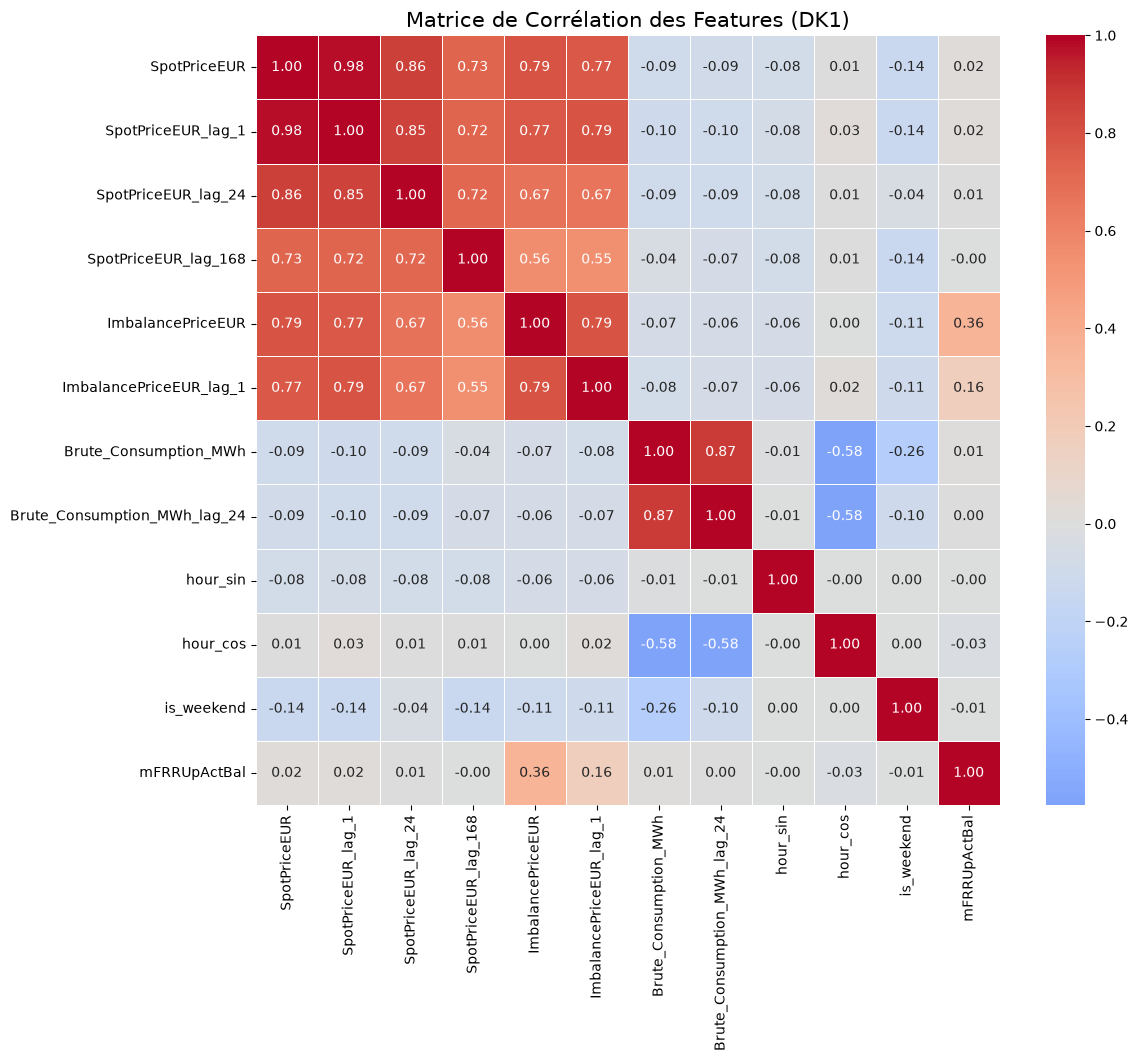

In [24]:
# 1. On sélectionne les colonnes pertinentes pour ne pas saturer le graphique
cols_to_analyze = [
    'SpotPriceEUR', 'SpotPriceEUR_lag_1', 'SpotPriceEUR_lag_24', 'SpotPriceEUR_lag_168',
    'ImbalancePriceEUR', 'ImbalancePriceEUR_lag_1', 
    'Brute_Consumption_MWh', 'Brute_Consumption_MWh_lag_24',
    'hour_sin', 'hour_cos', 'is_weekend', 'mFRRUpActBal'
]

# On se concentre sur DK1 pour la lisibilité (le comportement est similaire en DK2)
corr_matrix = df_clean[df_clean['PriceArea'] == 'DK1'][cols_to_analyze].corr()

# 2. Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de Corrélation des Features (DK1)', fontsize=15)
plt.show()

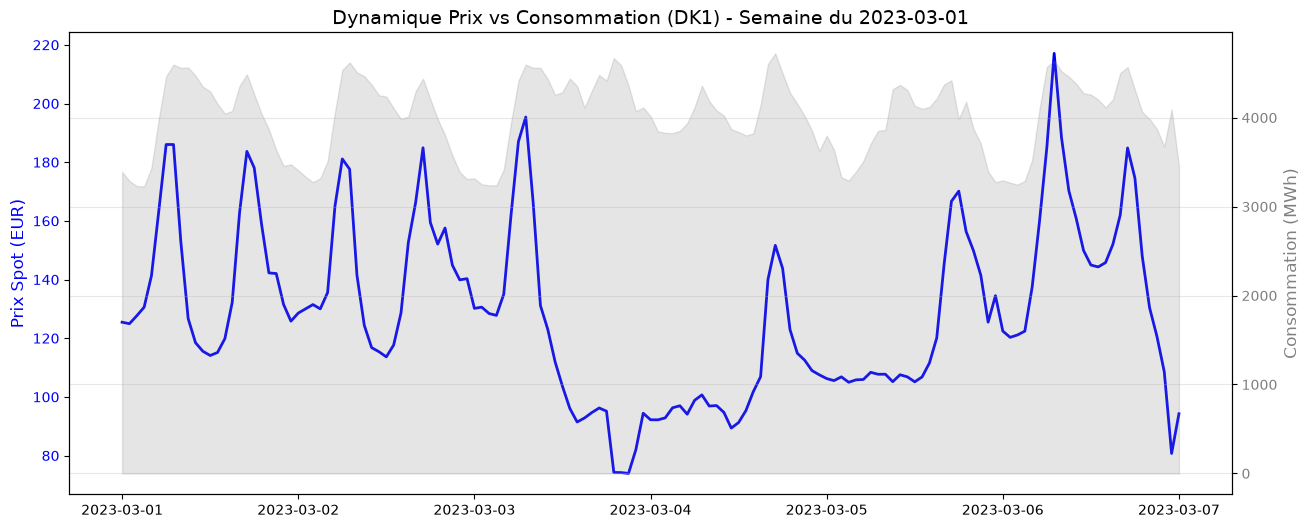

In [25]:
# Zoom sur une semaine type (ex: Mars 2023)
start_date = '2023-03-01'
end_date = '2023-03-07'
sample = df_clean[(df_clean['PriceArea'] == 'DK1') & (df_clean['HourUTC'].between(start_date, end_date))]

fig, ax1 = plt.subplots(figsize=(15, 6))

# Axe 1 : Prix Spot
ax1.plot(sample['HourUTC'], sample['SpotPriceEUR'], color='blue', label='Prix Spot EUR/MWh', lw=2)
ax1.set_ylabel('Prix Spot (EUR)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Axe 2 : Consommation
ax2 = ax1.twinx()
ax2.fill_between(sample['HourUTC'], sample['Brute_Consumption_MWh'], color='gray', alpha=0.2, label='Consommation MWh')
ax2.set_ylabel('Consommation (MWh)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

plt.title(f'Dynamique Prix vs Consommation (DK1) - Semaine du {start_date}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# On sépare proprement les deux zones à partir du dataset nettoyé et enrichi
df_dk1 = df_clean[df_clean['PriceArea'] == 'DK1'].copy()
df_dk2 = df_clean[df_clean['PriceArea'] == 'DK2'].copy()

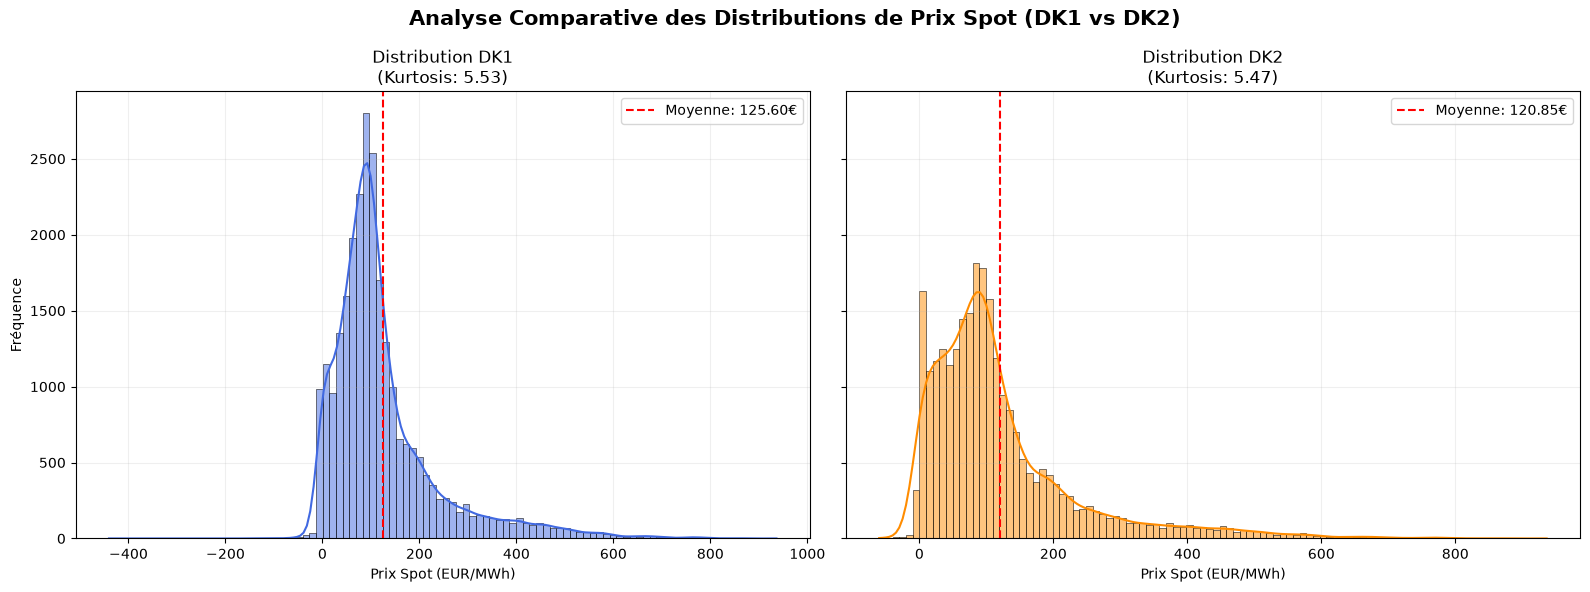

In [27]:
# ==========================================================
# 1. COMPARAISON DES DISTRIBUTIONS (Histogrammes côte à côte)
# ==========================================================
# Objectif : Valider visuellement la présence de "queues lourdes" (prix extrêmes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Zone DK1
sns.histplot(df_dk1['SpotPriceEUR'], kde=True, color='royalblue', ax=ax1, bins=100)
ax1.axvline(df_dk1['SpotPriceEUR'].mean(), color='red', linestyle='--', label=f"Moyenne: {df_dk1['SpotPriceEUR'].mean():.2f}€")
ax1.set_title(f"Distribution DK1\n(Kurtosis: {df_dk1['SpotPriceEUR'].kurt():.2f})", fontsize=12)
ax1.set_xlabel('Prix Spot (EUR/MWh)')
ax1.set_ylabel('Fréquence')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Zone DK2
sns.histplot(df_dk2['SpotPriceEUR'], kde=True, color='darkorange', ax=ax2, bins=100)
ax2.axvline(df_dk2['SpotPriceEUR'].mean(), color='red', linestyle='--', label=f"Moyenne: {df_dk2['SpotPriceEUR'].mean():.2f}€")
ax2.set_title(f"Distribution DK2\n(Kurtosis: {df_dk2['SpotPriceEUR'].kurt():.2f})", fontsize=12)
ax2.set_xlabel('Prix Spot (EUR/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('Analyse Comparative des Distributions de Prix Spot (DK1 vs DK2)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ==========================================================
# 2. TABLEAU COMPARATIF DES MÉTRIQUES CLÉS
# ==========================================================
# Objectif : Quantification stricte des écarts de marché et des prix négatifs
metrics_summary = pd.DataFrame({
    'Métrique': [
        'Prix Moyen (EUR)', 
        'Médiane (EUR)', 
        'Prix Maximum (EUR)', 
        'Prix Minimum (EUR)', 
        'Volatilité (Écart-type)',
        'Nombre d\'heures négatives', 
        'Pourcentage d\'heures négatives (%)',
        'Kurtosis (Indice d\'extravagance)'
    ],
    'DK1 (Jutland / Ouest)': [
        df_dk1['SpotPriceEUR'].mean(),
        df_dk1['SpotPriceEUR'].median(),
        df_dk1['SpotPriceEUR'].max(),
        df_dk1['SpotPriceEUR'].min(),
        df_dk1['SpotPriceEUR'].std(),
        (df_dk1['SpotPriceEUR'] < 0).sum(),
        (df_dk1['SpotPriceEUR'] < 0).mean() * 100,
        df_dk1['SpotPriceEUR'].kurt()
    ],
    'DK2 (Zélande / Est)': [
        df_dk2['SpotPriceEUR'].mean(),
        df_dk2['SpotPriceEUR'].median(),
        df_dk2['SpotPriceEUR'].max(),
        df_dk2['SpotPriceEUR'].min(),
        df_dk2['SpotPriceEUR'].std(),
        (df_dk2['SpotPriceEUR'] < 0).sum(),
        (df_dk2['SpotPriceEUR'] < 0).mean() * 100,
        df_dk2['SpotPriceEUR'].kurt()
    ]
}).round(3)

print("\n" + "="*60)
print("             TABLEAU COMPARATIF : DK1 VS DK2")
print("="*60)
print(metrics_summary.to_string(index=False))
print("="*60 + "\n")


             TABLEAU COMPARATIF : DK1 VS DK2
                          Métrique  DK1 (Jutland / Ouest)  DK2 (Zélande / Est)
                  Prix Moyen (EUR)                125.597              120.846
                     Médiane (EUR)                 96.065               91.570
                Prix Maximum (EUR)                936.280              936.310
                Prix Minimum (EUR)               -440.100              -60.040
           Volatilité (Écart-type)                114.723              115.493
         Nombre d'heures négatives                694.000              511.000
Pourcentage d'heures négatives (%)                  2.658                1.957
  Kurtosis (Indice d'extravagance)                  5.529                5.474



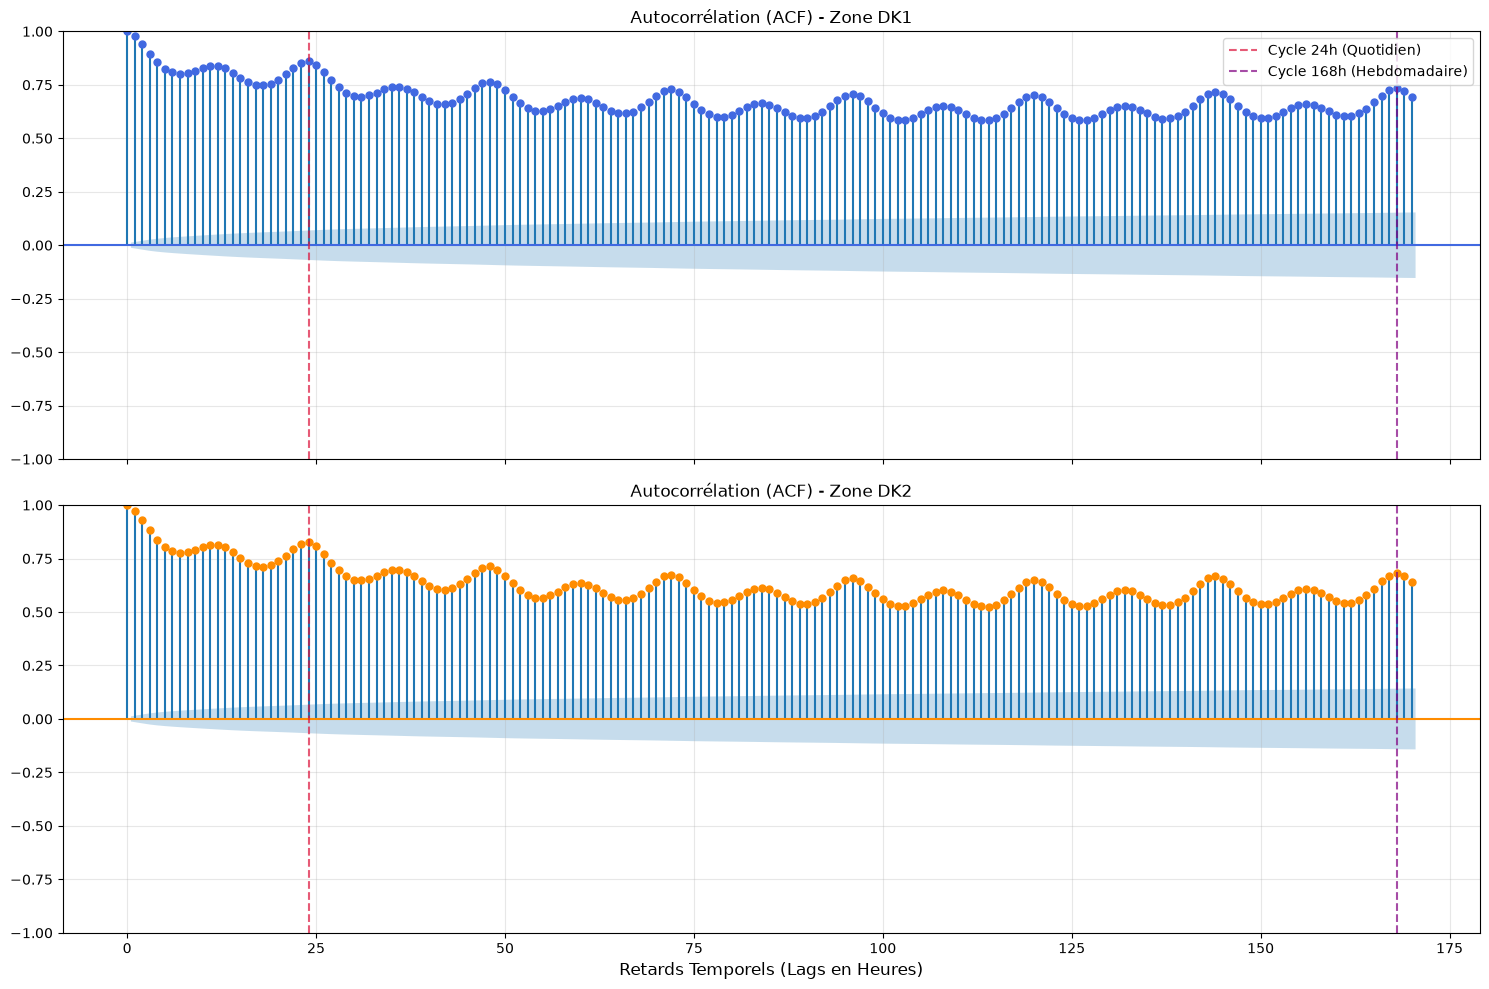

In [29]:
# ==========================================================
# 3. COMPARAISON DES SAISONNALITÉS (ACF)
# ==========================================================
# Objectif : Prouver la persistance des cycles de 24h et 168h sur les deux zones
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ACF DK1
plot_acf(df_dk1['SpotPriceEUR'], lags=170, ax=ax1, color='royalblue', title="Autocorrélation (ACF) - Zone DK1")
ax1.axvline(24, color='crimson', linestyle='--', alpha=0.7, label='Cycle 24h (Quotidien)')
ax1.axvline(168, color='purple', linestyle='--', alpha=0.7, label='Cycle 168h (Hebdomadaire)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ACF DK2
plot_acf(df_dk2['SpotPriceEUR'], lags=170, ax=ax2, color='darkorange', title="Autocorrélation (ACF) - Zone DK2")
ax2.axvline(24, color='crimson', linestyle='--', alpha=0.7)
ax2.axvline(168, color='purple', linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3)

plt.xlabel('Retards Temporels (Lags en Heures)', fontsize=12)
plt.tight_layout()
plt.show()